# Annotated `scope`: A Line-by-Line Walkthrough

`scope` is an open-source Python package for simulating ground-based, high-resolution cross-correlation spectroscopy (HRCCS) of exoplanet atmospheres. It's developed and maintained by Arjun Savel at the University of Maryland, College Park, and its official documentation lives at [scope-astr.readthedocs.io](https://scope-astr.readthedocs.io/en/latest/).

I'm **Sarunyapat (Pat) Phoompuang**, and I put this notebook together while working with `scope` for my own research (see the [main project](https://patsrnpt.github.io/Exoplanet-Atmosphere/intro.html) for context). The source code is well-written, but dense, understanding what a given function does often meant reading it line by line myself. This notebook is that reading, written down: an annotated walkthrough of `scope`'s core functions, explaining why each piece exists, not just what it does. Arjun gave permission for these annotations to live alongside the original code.

We'll cover how `scope` builds a simulated data cube from a planet and star model, layers in telluric absorption, blaze function, and photon noise, then removes large-scale trends with PCA, and how to read the resulting output files.

## Learning Goals

- Understand how `scope` builds a simulated HRCCS data cube: planet and star signal, telluric absorption, blaze function, and noise, layered step by step.

- Learn how PCA removes large-scale trends to isolate the planetary signal, and what gets lost in the process.

- Read and interpret `scope`'s output files: the CCF map, log-likelihood map, and the data cubes at each processing stage.

- Recognize which parameters in `run_simulation.py` matter for a given use case, rather than treating all 30+ as equally important.

## Table of Contents

## Table of Contents

- Imports
- Installation
- Quickstart
- `input.txt` File
- `run_simulation.py` File
  - `make_data`
  - `calc_log_likelihood`
  - `simulate_observation`
- `broadening.py`
  - `get_rot_ker`
- `ccf.py`
  - `calc_ccf`
- `input_output.py`
  - `parse_input_file`
  - Supporting Functions
- `logger.py`
  - `setup_logging`
- `noise.py`
  - `add_noise_cube`
- `tellurics.py`
  - `add_tellurics`
- `utils.py`
  - `doppler_shift_planet_star`
  - Supporting Functions
- Package Output
  - `input.txt` (Output Copy)
  - `A_noplanet_..._150.txt`
  - `ccfs_..._150.txt`
  - `just_tellurics_vary_airmass.txt`
  - `lls_..._150.txt`
  - `nopca_simdata_..._150.txt` and `simdata_..._150.txt`
- End of Tutorial
- About This Notebook

## Imports

This tutorial uses a few packages for the code examples and visualizations here:

- **numpy** – array operations and numerical computations
- **matplotlib** – plotting and visualizing data
- **pickle** – loading `scope`'s binary output files (data cubes, noise matrices, etc.)

These are separate from `scope`'s own dependencies, which come up once we get to installing and running the package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
import file_paths

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Installation

`scope`'s own docs cover installation too, but here's the from-source method I'd actually recommend, since it also gets you the data files the package needs to run:

```bash
python3 -m pip install -U pip
python3 -m pip install -U setuptools setuptools_scm pep517
git clone https://github.com/arjunsavel/scope
cd scope
python3 -m pip install -e .
```

This pulls in `scope`'s dependencies automatically, even ones you never import directly. A few worth knowing about, since they hint at what's happening under the hood:

- **numpy** – core numerical operations and array handling

- **astropy** – astronomical units, constants, and file formats

- **scipy** – convolution, interpolation, optimization

- **pandas** – reading and writing input/output files

- **jax** – numerical computing with automatic differentiation, used in `scope`'s core simulation functions

- **scikit-learn** – PCA and other trend-removal tools

- **emcee** / **pymc** – MCMC sampling and Bayesian inference, for parameter estimation

- **exoplanet** – orbital and light curve modeling

- **schwimmbad** – parallelizes simulations

- **tqdm** – progress bars during long-running loops

Next, download the data files `scope` needs:

```bash
cd src/scope
chmod +x download_data.bash
./download_data.bash
```

This creates a `scope` folder containing everything the package needs, and your terminal ends up inside it automatically. If you ever need to return to it later:

```bash
cd ~/scope/src/scope
```

## Quickstart

From inside that folder, run:

```bash
python run_simulation.py
```

If it works, you'll see a new `output` folder appear inside `scope`. If you've just downloaded the package and run this immediately, you'll likely hit:

```bash
ValueError: zero-size array to reduction operation minimum which has no identity
```

That means `input.txt` still has its default placeholder values, we'll fix that in the next section.

## `input.txt` File

Here's what `input.txt` looks like:

```bash
#·······································:
#                                       :
#    ▄▄▄▄▄   ▄█▄    ████▄ █ ▄▄  ▄███▄   :
#   █     ▀▄ █▀ ▀▄  █   █ █   █ █▀   ▀  :
# ▄  ▀▀▀▀▄   █   ▀  █   █ █▀▀▀  ██▄▄    :
#  ▀▄▄▄▄▀    █▄  ▄▀ ▀████ █     █▄   ▄▀ :
#            ▀███▀         █    ▀███▀   :
#                           ▀           :
#                                       :
#·······································:
Created:                2024-08-15
Author:                 Arjun Savel!
Planet name:            WASP-121 b

# Simulation setup

modelname              wasp_166_150seed_ld          # name of the model. used for saving the output files.
seed                   150               # seed for the random number generator when generating noisy data. set to None for a random seed.
log_level              DEBUG              # logging level above which statements are printed. Supported levels are ``DEBUG``, ``INFO``, ``WARNING``, ``ERROR``, and ``CRITICAL``.

# Filepaths
planet_spectrum_path    path/to/planet_spectrum.pic
star_spectrum_path      path/to/star_spectrum.txt
data_cube_path          path/to/data_cube.pic
# snr_path              path/to/snr_file.json # only required for CRIRES+ simulations

# Astrophysical Parameters. Can specify DATABASE to pull based on name for parameters with [DB]
Rp                     DATABASE          # planetary radius in Jupiter radii. [DB]
Mp                     DATABASE          # planetary mass in Jupiter masses. [DB]
e                      DATABASE          # eccentricity of the planet's orbit. [DB]
omega                  0                 # argument of periastron of the planet's orbit, in degrees. [DB]
b                      DATABASE          # impact parameter of the planet's orbit. [DB]
Rstar                  DATABASE          # stellar radius, in solar radii. [DB]
Mstar                  DATABASE          # stellar mass, in solar masses. [DB]
Kmag                   DATABASE          # K-band magnitude of the star. [DB]
kp                     NULL              # expected planetary orbital velocity assuming circular orbit, in km/s. input NULL if you'd like to calculate from orbital parameters.
v_sys                  0.0          # systemic velocity, in km/s.  [DB]
v_rot                  NULL              # equatorial rotational velocity. input NULL if you'd like to calculate from orbital parameters.
P_rot                  DATABASE          # orbital period of the planet, in days. [DB]
a                      DATABASE          # semi-major axis of the planet, in AU. [DB]
scale                  1.0               # scaling factor for the model spectrum.
LD                     True              # whether to include limb darkening in the simulation or not. only matters if observation is set to transmission.
u1                     0.1               # first quadratic limb darkening coefficient. not used if limb_darkening is set to False or if observation is set to emission.
u2                     0.1               # second quadratic limb darkening coefficient. not used if limb_darkening is set to False or if observation is set to emission.
include_rm             False             # *experimental*. Whether to include Rossiter-McLaughlin effect in the simulation or not. only matters if observation is set to transmission.
v_rot_star             3                 # equatorial rotational velocity of the star in km/s. only matters if include_rm is set to True. and observation is set to transmission. [DB]
lambda_misalign        0                 # misalignment angle of the planet's orbit with respect to the star's rotation axis, in degrees. only matters if include_rm is set to True. and observation is set to transmission. [DB]
inc                    90.0              # inclination of the planet's orbit with respect to the line of sight, in degrees. only matters if include_rm is set to True. and observation is set to transmission.

# Instrument Parameters
instrument             IGRINS        # name of the spectrograph to simulate. currently spectrographs are ``IGRINS`` and ``CRIRES+``.
blaze                  True          # whether to include a blaze function or not.
wav_error              False         # whether to include wavelength solution errors or not.
order_dep_throughput   True          # whether to include order-dependent throughput variations.
vary_throughput        True          # whether to include throughput variations. IGRINS variations fit to WASP-77Ab emission data.

# Observation Parameters
observation            transmission      # type of observation to perform. supported observations are ``emission`` and ``transmission``.
phase_start            0           # phase of the beginning of the observations. 0 is center of transit, 0.5 is secondary eclipse. If DATABASE, just the transit duration. [DB]
phase_end              1             # phase of the end of the observations. 0 is center of transit, 0.5 is secondary eclipse. If DATABASE, just the transit duration. [DB]
n_exposures            50             # number of exposures to simulate. sets the phases of the exposures. if set to 0, the minimum number of exposures that prevent pixel crossing for the provided instrument is used.
star                   True          # whether to include the star in the simulation. In general, you'd like to!
telluric               True          # whether to include tellurics in the simulation. In general, you'd like to!
SNR                    147           # signal-to-noise ratio of the observations, per pixel. I.e., what sets the photon counts at the detector.

tell_type              data-driven   # type of telluric simulation. supported modes are ``ATRAN`` and ``data-driven``.
time_dep_tell          False         # whether the tellurics are time-dependent or not.

# Analysis Parameters
pca_removal            subtract      # how to remove the PCA fit. options are ``subtract`` and ``divide``; the former weights absolute errors, and the latter relative errors.
n_princ_comp           4             # number of principal components to remove from the simulated data before cross-correlation.
divide_out_of_transit  False         # *experimental*. Whether to divide the in-transit data by median out-of-transit or not. only used if observation is set to transmission.
out_of_transit_dur     1.          # *experimental*. Duration of the out-of-transit data, in units of transit duration. only used if observation is set to transmission and divide_out_of_transit is set to True.
```

The format of the `input.txt` file shown above is different from the version you get when you download the package. I've already adjusted this file so it runs properly and avoids the error mentioned earlier. Here are the variables I updated to get the package working:

- **Planet name** (optional): set this to match your target planet. I used WASP-121 b for my project.
- **`planet_spectrum_path`**: this should point to your dataset. If you don't have one, you can use the file `best_fit_spectrum_tran_gj1214_steam_nir.pic`, included in the package's data folder.
- **`star_spectrum_path`**: enter the path to your star spectrum file. If you don't have your own, the default value works fine.
- **`data_cube_path`**: you can specify your own dataset path here, but the default is already valid if not.
- **`snr_path`**: set this to your dataset path if you have one. If you'd rather not use this variable, comment it out with a `#`.
- **`kp`** (optional): set this to `NULL` if you want the package to calculate it from your dataset, or leave the default value.
- **`v_rot`** (optional): like `kp`, set this to `NULL` for automatic calculation, or leave the default value.
- **`phase_start`**: replace `DATABASE` with a numerical value, such as `0` for your initial phase.
- **`phase_end`**: replace `DATABASE` with a numerical value, such as `1` for your final phase.
- **`n_exposures`** (optional): you don't need to change this unless you want a different number of exposures. I set it to 50, matching real IGRINS observation cadence.
- **`SNR`**: the default that ships with the package isn't a valid number. I set this to 147, the typical per-frame SNR from Night 1 of the actual IGRINS transit observations of WASP-121b (Table 2, [Phase-resolving the absorption signatures of water and carbon monoxide in the atmosphere of the ultra-hot Jupiter WASP-121b with GEMINI-S/IGRINS](https://arxiv.org/pdf/2406.09641)).

Once you've updated these variables, the package should run without errors. Keep in mind that increasing the SNR or the number of exposures will generally make the program take longer to complete.

## `run_simulation.py` File

At this point, the package should run successfully. This file is where everything comes together: it's the script that actually builds the simulated data cube, evaluates how well a model fits it, and generates the observation you'd analyze. We'll walk through its two main functions, `make_data` and `calc_log_likelihood`, along with `simulate_observation`, the function that ties them together.

### `make_data`

This is the core function of the whole package: it builds a full simulated HRCCS data cube by layering the planet's Doppler-shifted signal, the star, tellurics, and instrumental noise on top of each other, then optionally removing large-scale trends with PCA.

Rather than list all 30+ parameters up front, we'll introduce each one as it becomes relevant. The function has one job: turn a planet model and a star model into something that looks like what a real telescope would record.

```python
def make_data(
    scale, wlgrid, wl_model, Fp_conv, Fstar_conv,
    n_order, n_exposure, n_pixel, phases, Rp_solar, Rstar,
    seed=42, do_pca=True, blaze=False, tellurics=False, n_princ_comp=4,
    v_sys=0.0, Kp=192.06, star=False, SNR=0, rv_semiamp_orbit=0.3229,
    observation="emission", tell_type="ATRAN", time_dep_tell=False,
    wav_error=False, order_dep_throughput=False,
    a=1, u1=0.3, u2=0.3, LD=True, b=0.0,
    divide_out_of_transit=False, out_of_transit_dur=0.1,
    v_sys_measured=0.0, vary_throughput=True,
    instrument="IGRINS", pca_removal="subtract",
):
    ...
```

Most of these parameters are toggles for optional effects (`blaze`, `tellurics`, `wav_error`, `do_pca`), each one turns on a piece of realism you can add or strip away. The handful that matter every run are `wlgrid`, `wl_model`, `Fp_conv`, `Fstar_conv` (the wavelength grids and model spectra), `Kp` and `v_sys` (the orbital motion that produces the Doppler signature), and `n_order`/`n_exposure`/`n_pixel` (the shape of the output). We'll meet the rest as they come up.

```python
np.random.seed(seed)
```

Everything downstream, noise, telluric variation, is drawn from `numpy`'s random number generator. Fixing the seed here means two runs with identical inputs produce identical output, which matters if you're debugging or comparing runs across resolutions.

```python
rv_planet, rv_star = calc_rvs(v_sys, v_sys_measured, Kp, rv_semiamp_orbit, phases)
```

This is where the orbital physics enters the simulation. `calc_rvs` converts orbital parameters, systemic velocity (`v_sys`), the planet's orbital semi-amplitude (`Kp`), and the star's reflex motion (`rv_semiamp_orbit`), into a radial velocity at each orbital phase. Every Doppler shift you'll see later in the pipeline traces back to these two arrays.

```python
flux_cube = np.zeros((n_order, n_exposure, n_pixel))
pca_noise_matrix = np.zeros((n_order, n_exposure, n_pixel))
```

Two empty cubes shaped `(spectral order, exposure, pixel)`, this 3D shape is scope's fundamental data structure, and it reappears in nearly every output file the package produces. `flux_cube` will hold the actual simulated signal; `pca_noise_matrix` will later capture what PCA removes, useful for checking how much real signal got stripped out alongside the noise.

```python
for order in range(n_order):
    wlgrid_order = np.copy(wlgrid[order,])
    flux_cube[order] = doppler_shift_planet_star(
        flux_cube[order], n_exposure, phases, rv_planet, rv_star,
        wlgrid_order, wl_model, Fp_conv, Rp_solar, Fstar_conv, Rstar,
        u1, u2, a, b, LD, scale, star, observation,
    )
```

Real spectrographs split light into discrete spectral orders rather than one continuous range, so this loop processes each order independently, with its own copy of the wavelength grid (copied so shifts applied here don't leak into the original array used elsewhere). `doppler_shift_planet_star` is where the planet's motion shows up: it shifts the model spectrum according to `rv_planet` at each exposure. This is the same signature my first tutorial's wind-speed measurements are built to recover.

```python
throughput_baselines = np.loadtxt(abs_path + "/data/throughputs.txt")
flux_cube = detrend_cube(flux_cube, n_order, n_exposure)
```

`detrend_cube` normalizes flux across orders and exposures so the simulated signal is on a consistent scale, this gets called repeatedly throughout the function, every time a new effect is layered in, to keep things numerically well-behaved before the next step.

```python
if vary_throughput:
    for i in range(flux_cube.shape[1]):
        if i >= 79:
            j = 79 - i
            throughput_baseline = throughput_baselines[j]
        else:
            throughput_baseline = throughput_baselines[i]
        throughput_factor = throughput_baseline / np.nanpercentile(flux_cube[:, i, :], 90)
        flux_cube[:, i, :] *= throughput_factor
```

Real instruments don't transmit light equally well at every moment, throughput drifts over an observing sequence (temperature changes, guiding errors, etc.). This block applies a measured throughput curve (loaded from real IGRINS/WASP-77Ab data) exposure by exposure. The `i >= 79` branch mirrors the throughput curve past index 79 rather than extrapolating, since the reference data only covers that many points.

```python
if tellurics:
    if instrument != "IGRINS":
        raise NotImplementedError(
            "Only IGRINS data is currently supported for telluric simulations."
        )
    flux_cube = add_tellurics(
        wlgrid, flux_cube, n_order, n_exposure,
        vary_airmass=True, tell_type=tell_type, time_dep_tell=time_dep_tell,
    )
    just_tellurics = np.ones_like(flux_cube)
    just_tellurics = add_tellurics(
        wlgrid, just_tellurics, n_order, n_exposure,
        vary_airmass=True, tell_type=tell_type, time_dep_tell=time_dep_tell,
    )
    flux_cube[flux_cube < 0.0] = 0.0
    just_tellurics[just_tellurics < 0.0] = 0.0
flux_cube = detrend_cube(flux_cube, n_order, n_exposure)
```

`add_tellurics` multiplies in Earth's atmospheric absorption, the same effect my first tutorial's README describes as a reason ground-based spectra need correction. Note it's called twice: once on the real flux cube, and once on an array of pure ones, the second call isolates *just* the telluric transmission pattern on its own, useful later for comparison or correction, without needing to re-derive it from the full signal.

```python
if blaze:
    flux_cube = add_blaze_function(wlgrid, flux_cube, n_order, n_exposure)
    flux_cube[flux_cube < 0.0] = 0.0
flux_cube[np.isnan(flux_cube)] = 0.0
flux_cube = detrend_cube(flux_cube, n_order, n_exposure)
flux_cube[np.isnan(flux_cube)] = 0.0
```

The blaze function is the grating's own wavelength-dependent sensitivity curve, my first tutorial's README already introduces this term. Applying it here means the simulated continuum isn't flat, it dips and peaks the way a real spectrograph's output would, a hardware effect, independent of anything astrophysical.

```python
if np.any(SNR > 0):
    noise_model = instrument if order_dep_throughput else "constant"
    flux_cube = add_noise_cube(flux_cube, wlgrid, SNR, noise_model=noise_model)
flux_cube = detrend_cube(flux_cube, n_order, n_exposure)
```

`SNR = 0` is a deliberate sentinel value meaning "skip noise entirely," useful for testing the pipeline's other effects in isolation. When SNR is set, `noise_model` decides whether the noise level is flat across all wavelengths ("constant") or varies by spectral order to mimic a specific instrument's real sensitivity curve.

```python
if wav_error:
    doppler_shifts = np.loadtxt("data/doppler_shifts_w77ab.txt")
    flux_cube = change_wavelength_solution(wlgrid, flux_cube, doppler_shifts)
flux_cube = detrend_cube(flux_cube, n_order, n_exposure)
flux_cube[np.isnan(flux_cube)] = 0.0
flux_cube_nopca = flux_cube.copy()
```

`wav_error` simulates a miscalibrated wavelength solution, small, real Doppler-like shifts unrelated to the planet, loaded from measured WASP-77Ab data. This is a good stress-test: if my analysis can still recover the true wind speed with this turned on, it's robust to a real calibration imperfection, not just clean synthetic data. Right after this, `flux_cube_nopca` saves a snapshot before PCA runs, this becomes the `nopca_simdata` output file we'll see later.

There's one more optional branch here, for transmission spectra with `divide_out_of_transit=True`, which builds a separate out-of-transit baseline (star + tellurics + blaze + noise, no planet) and divides it out of the main flux cube. It's a niche option mainly used for transit-specific normalization, and follows the same pattern of effects already covered above, so we won't walk through it line by line here.

```python
if do_pca:
    for j in range(n_order):
        flux_cube[j] -= np.mean(flux_cube[j])
        flux_cube[j] /= np.std(flux_cube[j])
        flux_cube[j], pca_noise_matrix[j] = perform_pca(
            flux_cube[j], n_princ_comp, pca_removal=pca_removal
        )
else:
    for j in range(n_order):
        for i in range(n_exposure):
            flux_cube[j][i] -= np.mean(flux_cube[j][i])

if np.all(pca_noise_matrix == 0):
    pca_noise_matrix = np.ones_like(pca_noise_matrix)
```

This is the step my first tutorial's Learning Goals point to: removing large-scale trends via PCA so the fainter planetary signal becomes detectable underneath the star and telluric contributions. Each order is standardized (zero mean, unit variance) before PCA runs, since PCA is sensitive to scale, an order with naturally larger flux values would otherwise dominate the decomposition regardless of how much real signal it contains.

```python
if tellurics:
    return pca_noise_matrix, flux_cube, flux_cube_nopca, just_tellurics
return pca_noise_matrix, flux_cube, flux_cube_nopca, np.ones_like(flux_cube)
```

Four outputs, always in the same order: the PCA-removed trends, the final cleaned flux cube, the pre-PCA version, and the telluric-only cube (or an array of ones if tellurics were never added, so downstream code doesn't need a separate code path to handle their absence).

### `calc_log_likelihood`

Where `make_data` builds a synthetic dataset, `calc_log_likelihood` does the opposite: given a data cube and a set of trial parameters, it asks how well a model matching those parameters fits. This is the function a retrieval or grid search calls repeatedly, once per candidate `(v_sys, Kp)` pair, to figure out which velocities best explain the data.

```python
def calc_log_likelihood(
    v_sys, Kp, scale, wlgrid, wl_model, Fp_conv, Fstar_conv, flux_cube,
    n_order, n_exposure, n_pixel, phases, Rp_solar, Rstar,
    rv_semiamp_orbit, A_noplanet,
    do_pca=True, n_princ_comp=4, star=False, observation="emission",
    a=1, u1=0.3, u2=0.3, LD=True, b=0.0,
    v_sys_measured=0.0, pca_removal="subtract",
):
    ...
```

Most of these parameters describe the same system as `make_data`, the planet's orbit, the star, the instrument, since this function needs to build a model spectrum under the same physical assumptions before comparing that model to real data. The two new arguments are `flux_cube` (the data being tested) and `A_noplanet` (the non-planet component `make_data` separated out earlier), both feed into the comparison step below.

```python
rv_planet, rv_star = calc_rvs(v_sys, v_sys_measured, Kp, rv_semiamp_orbit, phases)
CCF = 0.0
logL = 0.0
```

Same radial velocity calculation as `make_data`, but now `v_sys` and `Kp` are the *trial* values being tested, not the true injected ones. `CCF` and `logL` start at zero and accumulate across spectral orders in the loop below, since the final answer sums every order's contribution.

```python
for order in range(n_order):
    wlgrid_order = np.copy(wlgrid[order,])
    model_flux_cube = np.zeros((n_exposure, n_pixel))

    model_flux_cube = doppler_shift_planet_star(
        model_flux_cube, n_exposure, phases, rv_planet, rv_star,
        wlgrid_order, wl_model, Fp_conv, Rp_solar, Fstar_conv, Rstar,
        u1, u2, a, b, LD, scale, star, observation,
        reprocessing=True,
    )
```

This builds a fresh model spectrum, shifted according to the trial `v_sys`/`Kp`, one order at a time, matching `make_data`'s Doppler loop. The one difference: `reprocessing=True`. This tells the function it's evaluating a candidate model against existing data, not generating a new dataset from scratch, which changes some internal handling inside `doppler_shift_planet_star`.

```python
if do_pca:
    model_flux_cube *= A_noplanet[order]
    model_flux_cube, _ = perform_pca(model_flux_cube, n_princ_comp, pca_removal=pca_removal)
```

This is what makes the comparison fair. Since PCA was applied to the real data (removing large-scale trends), the model needs the same treatment before it can be compared apples-to-apples. Multiplying by `A_noplanet` first reintroduces the trend PCA originally removed from the real data, so running PCA on the model here mirrors what happened to the observations, rather than comparing a clean model against processed data.

```python
logl, ccf = calc_ccf(model_flux_cube, flux_cube[order], n_pixel)
CCF += ccf
logL += logl
```

`calc_ccf` (next section) does the actual comparison for this one order, how well does the model line up with the real data? Its two outputs get added to the running totals, so by the time the loop finishes, `CCF` and `logL` reflect the combined evidence across every spectral order, not just one.

```python
return logL, CCF
```

The two numbers this function exists to produce: `logL` tells us how probable this `(v_sys, Kp)` pair is given the data, higher is better. `CCF` is the raw cross-correlation strength, this is the number that, computed across a whole grid of trial velocities, produces the CCF maps and log-likelihood maps we'll see later in this notebook.

### `simulate_observation`

This is the function `run_simulation.py` actually calls. It takes everything from `input.txt`, builds one simulated dataset with `make_data`, then runs a full grid search over trial `Kp` and `v_sys` values with `calc_log_likelihood`, saving results as it goes so a long run can be interrupted without losing progress.

```python
def simulate_observation(
    planet_spectrum_path=".", star_spectrum_path=".", data_cube_path=".",
    phase_start=0, phase_end=1, n_exposures=10, observation="emission",
    blaze=True, n_princ_comp=4, star=True, SNR=250, telluric=True,
    tell_type="data-driven", time_dep_tell=False, wav_error=False,
    rv_semiamp_orbit=0.3229, order_dep_throughput=True,
    Rp=1.21, Rstar=0.955, kp=192.02, v_rot=4.5, scale=1.0, v_sys=0.0,
    modelname="yourfirstsimulation", divide_out_of_transit=False,
    out_of_transit_dur=0.1, include_rm=False, v_rot_star=3.0,
    a=0.033, lambda_misalign=0.0, inc=90.0, seed=42, LD=True,
    vary_throughput=True, instrument="IGRINS", snr_path=None,
    planet_name="yourfirstplanet", n_kp=200, n_vsys=200,
    pca_removal="subtract", **kwargs,
):
    ...
```

Most of these parameters map directly onto `input.txt`, this function is what `parse_input_file` feeds into, so every line in that config file corresponds to an argument here. Two are new and worth flagging: `n_kp` and `n_vsys`, which control the resolution of the grid search itself, not the simulated spectrum.

```python
outdir = abs_path + f"/output/{modelname}"
make_outdir(outdir)

output_args = locals()
output_args.update(kwargs)
write_input_file(output_args, output_file_path=f"{outdir}/input.txt")
```

Before doing any actual work, the function writes its own settings back out to disk. This is what makes a run reproducible, the `input.txt` saved in your output folder isn't just a copy of what you typed in, it's the *exact* set of parameters used, including any values filled in from `DATABASE` lookups.

```python
phases = np.linspace(phase_start, phase_end, n_exposures)
Rp_solar = Rp * rjup_rsun

Kp_array = np.linspace(kp - 100, kp + 100, n_kp)
v_sys_array = np.linspace(v_sys - 100, v_sys + 100, n_vsys)
```

The orbital phases get built from `phase_start`/`phase_end`, same array shape used throughout `make_data`. The two trial grids, `Kp_array` and `v_sys_array`, span ±100 km/s around the nominal values, this range and the grid density (`n_kp`, `n_vsys`) directly determine how fine or coarse the eventual CCF and log-likelihood maps will look.

```python
if instrument == "IGRINS":
    n_order, n_pixel = (44, 1848)
    mike_wave, mike_cube = pickle.load(open(data_cube_path, "rb"), encoding="latin1")
    wl_cube_model = mike_wave.copy().astype(np.float64)
elif instrument == "CRIRES+":
    n_order, n_pixel, wl_cube_model, SNR = read_crires_data(snr_path)
```

The 44-order, 1848-pixel shape is IGRINS-specific, hardcoded here rather than read from a file, since that's simply IGRINS's fixed instrument geometry. CRIRES+ instead reads its shape and SNR straight from a data file, since `scope`'s CRIRES+ support pulls real observational metadata rather than assuming fixed values.

```python
wl_model, Fp, Fstar = np.load(planet_spectrum_path, allow_pickle=True)
wl_model = wl_model.astype(np.float64)

rot_ker = get_rot_ker(v_rot, wl_model, observation)
Fp_conv_rot = np.convolve(Fp, rot_ker, mode="same")

instrument_kernel = get_instrument_kernel(instrument)
Fp_conv = np.convolve(Fp_conv_rot, instrument_kernel, mode="same")
```

Two separate convolutions happen here, easy to conflate but physically distinct. `rot_ker` broadens the spectrum from the *planet's own rotation*, a real planet isn't a point source, it's a rotating body, so its lines are inherently a bit smeared even before an instrument sees them. `instrument_kernel` then applies a second broadening from the *spectrograph's* finite resolution, this is the same effect my first tutorial's `degrade_resolution` function models, just implemented differently here.

```python
star_wave, star_flux = np.loadtxt(star_spectrum_path).T

if include_rm:
    star_flux, _ = make_stellar_disk(
        star_flux, star_wave, v_rot_star, phases, Rstar, inc, lambda_misalign, a, Rp
    )

Fstar_conv = get_star_spline(star_wave, star_flux, wl_model, instrument_kernel, smooth=False)
```

`include_rm` toggles the Rossiter-McLaughlin effect, a real but subtle signature that appears when a planet transits and briefly blocks part of a rotating star's surface, distorting the star's own spectral lines in a time-dependent way. It's off by default, since it only matters for transmission spectra with specific orbital geometries, and adds real complexity when it matters.

```python
lls, ccfs = np.zeros((n_kp, n_vsys)) * np.nan, np.zeros((n_kp, n_vsys)) * np.nan
```

Both result grids start as NaN rather than zero, deliberately. Zero would be a valid log-likelihood or CCF value, so it couldn't distinguish "computed and happens to be zero" from "not computed yet." NaN can't be confused with a real result, useful if a long grid search gets interrupted partway through.

```python
A_noplanet, flux_cube, flux_cube_nopca, just_tellurics = make_data(
    scale, wl_cube_model, wl_model, Fp_conv, Fstar_conv,
    n_order, n_exposures, n_pixel, phases, Rp_solar, Rstar,
    seed=seed, do_pca=True, blaze=blaze, n_princ_comp=n_princ_comp,
    tellurics=telluric, v_sys=v_sys, star=star, Kp=kp, SNR=SNR,
    rv_semiamp_orbit=rv_semiamp_orbit, tell_type=tell_type,
    time_dep_tell=time_dep_tell, wav_error=wav_error,
    order_dep_throughput=order_dep_throughput, observation=observation,
    divide_out_of_transit=divide_out_of_transit, out_of_transit_dur=0.1,
    v_sys_measured=v_sys, LD=LD, instrument=instrument, pca_removal=pca_removal,
)
```

This is the one call to `make_data` we walked through earlier, everything up to this point exists to prepare its inputs. The dataset it returns here is treated as "the observation", generated once, then compared against many trial models in the grid search that follows.

```python
run_name = f"{n_princ_comp}_NPC_{blaze}_blaze_{star}_star_{telluric}_telluric_{round(np.mean(SNR))}_SNR_{tell_type}_{time_dep_tell}_{wav_error}_{order_dep_throughput}_{seed}"
save_data(outdir, run_name, flux_cube, flux_cube_nopca, A_noplanet, just_tellurics)
```

That long, underscore-heavy filename you'll see in the output folder isn't arbitrary, it's `run_name`, and every field in it corresponds to a setting used for that specific run. This is what makes it possible to tell two output files apart without opening either one, the settings are encoded right in the name.

```python
for l, Kp in tqdm(enumerate(Kp_array), total=len(Kp_array), desc="looping PCA over Kp"):
    for k, v_sys in enumerate(v_sys_array):
        res = calc_log_likelihood(
            v_sys, Kp, scale, wl_cube_model, wl_model, Fp_conv, Fstar_conv,
            flux_cube, n_order, n_exposures, n_pixel, phases, Rp_solar, Rstar,
            rv_semiamp_orbit, do_pca=True, n_princ_comp=n_princ_comp,
            A_noplanet=A_noplanet, star=star, observation=observation,
            v_sys_measured=v_sys, LD=LD, pca_removal=pca_removal,
        )
        lls[l, k], ccfs[l, k] = res

    save_results(outdir, run_name, lls, ccfs)
```

This is the grid search itself: every combination of trial `Kp` and `v_sys` gets its own call to `calc_log_likelihood`, the function we just walked through, comparing a model built at that velocity pair against the one real dataset generated above. `save_results` runs after each outer loop over `Kp`, not after every single point, a checkpoint frequent enough to avoid losing much work, without slowing the loop down by saving on every innermost iteration.

## `broadening.py`

### `get_rot_ker`

This function computes the rotational broadening kernel we called back in `simulate_observation`, the smearing effect a planet's (or star's) own rotation adds to its spectral lines, before any instrument gets involved. Most of the function body is validation and error handling wrapped around one physics calculation, so we'll focus there.

```python
def get_rot_ker(v_sin_i, wavelengths, observation="emission"):
    if observation not in ["emission", "transmission"]:
        raise RotationalBroadeningError(
            f"observation must be 'emission' or 'transmission', got '{observation}'"
        )

    if not isinstance(wavelengths, jnp.ndarray):
        wavelengths = jnp.array(wavelengths)
    if isinstance(v_sin_i, (list, np.ndarray)):
        v_sin_i = jnp.array(v_sin_i)

    if wavelengths.ndim != 1:
        raise RotationalBroadeningError(f"wavelengths must be 1D array, got shape {wavelengths.shape}")
    if wavelengths.size < 2:
        raise RotationalBroadeningError("wavelength array must have at least 2 points")
    if isinstance(v_sin_i, (float, int)) and v_sin_i <= 0:
        raise RotationalBroadeningError(f"v_sin_i must be positive, got {v_sin_i}")
```

The bulk of this section is guard rails, not physics: confirming `observation` is a recognized value, converting inputs to JAX arrays so the rest of the function can rely on a consistent type, and catching a couple of obviously invalid inputs (a 2D wavelength array, a negative rotation velocity) before they'd otherwise fail somewhere less obvious, deeper in the calculation.

```python
    kernel = get_rotational_kernel(
        v_sin_i, wavelengths, is_transmission=(observation == "transmission")
    )

    if jnp.any(jnp.isnan(kernel)):
        raise RotationalBroadeningError("Kernel calculation failed - check inputs")

    return kernel
```

This is where the actual physics happens, inside `get_rotational_kernel`, which this function wraps rather than reimplements. The kernel shape differs by observation type: transmission uses $\frac{1}{\pi\sqrt{1-x^2}}$, emission uses $\sqrt{1-x^2}$, both classic forms for how a rotating disk's line-of-sight velocities spread light across wavelength, with $|x| \geq 1$ (outside the disk) set to zero and the whole kernel normalized to sum to one. Note that `v_sin_i`, projected rotational velocity, is the standard way this quantity is expressed in the literature, since we only ever observe the component of rotation along our line of sight, not a planet's true rotation speed.

The NaN check afterward exists because a malformed kernel would otherwise propagate silently into every downstream convolution, corrupting results in a way that's hard to trace back to its source. Catching it here, right where it's produced, means a bad kernel fails loudly instead of quietly.

## `ccf.py`

### `calc_ccf`

This is the function underneath every log-likelihood and CCF value in the notebook so far, the actual comparison between a model and a slice of real data. It's short, but every line is doing real statistical work, this is the more rigorous cousin of the custom cross-correlation function from my first tutorial: same core idea (does the model line up with the data?), but grounded in the Brogi & Line (2019) likelihood framework rather than a simpler normalized dot product.

```python
def calc_ccf(model_flux, data_arr_slice, n_pixel):
    model_vector = jnp.subtract(model_flux, jnp.vstack(jnp.mean(model_flux, axis=1)))
```

The model gets mean-subtracted here, row by row, the same pre-whitening step my first tutorial's custom CCF function does before comparing spectra. This removes the continuum level so the comparison responds to spectral *shape*, not overall brightness, which would otherwise swamp the much subtler signature the cross-correlation is actually trying to detect.

```python
    variance_model = jnp.var(model_vector, axis=1)
    variance_data = jnp.var(data_arr_slice, axis=1)
    cross_variance = (model_vector * data_arr_slice).sum(axis=1) / n_pixel
```

Three quantities, all computed row by row (one row per exposure): how much the model varies, how much the real data varies, and how much they vary *together*. `cross_variance` is the heart of it, the average of the model and data multiplied together, this is large and positive when the model's ups and downs line up with the data's, and small or negative when they don't.

```python
    ccf = (cross_variance / jnp.sqrt(variance_data * variance_model)).sum()
```

Dividing by the square root of both variances turns the raw cross-variance into a normalized correlation, bounded in a way that doesn't depend on the absolute scale of either signal. Summing across all exposures gives one scalar CCF value per spectral order, matching what `calc_log_likelihood` expects back.

```python
    logl = (
        -0.5 * n_pixel * jnp.log(variance_data + variance_model - 2.0 * cross_variance)
    ).sum()

    return logl, ccf
```

This is the piece my first tutorial's simpler CCF function doesn't have: a proper log-likelihood, not just a correlation strength. The term inside the log, `variance_data + variance_model - 2·cross_variance`, is the variance of the *residual* between model and data (the same algebra as $\text{Var}(a - b) = \text{Var}(a) + \text{Var}(b) - 2\,\text{Cov}(a,b)$). A smaller residual variance means the model explains the data well, and pushes `logl` higher. This is what makes a proper grid search over `Kp` and `v_sys` statistically meaningful, rather than just comparing correlation strengths, which don't have as direct a probabilistic interpretation.

## `input_output.py`

### `parse_input_file`

This is the function that turns the `input.txt` file from earlier into an actual Python dictionary `scope` can use, handling type conversion, database lookups, and validation along the way.

```python
def parse_input_file(file_path, database_path="data/default_params_exoplanet_archive.csv", **kwargs):
    with open(file_path, "r") as file:
        content = file.readlines()

    data_lines, planet_name, author = unpack_lines(content)

    df = pd.read_csv(
        io.StringIO("\n".join(data_lines)),
        sep=r"\s+", header=None, names=["parameter", "value"], comment="#",
    )
    data = dict(zip(df["parameter"], df["value"]))
    data["planet_name"] = planet_name
    data["author"] = author
```

The file gets read as plain text first, then handed to `pandas` as if it were a two-column, whitespace-separated table, a neat trick, since it means `input.txt` doesn't need to be valid CSV or JSON, just consistently spaced. `unpack_lines` pulls the planet name and author out of the header before the rest gets parsed as parameter/value pairs.

```python
    astrophysical_params = ["Rp", "Rp_solar", "Rstar", "kp", "v_rot", "v_sys", "P_rot", "a", "u1", "e", "b", "u2", "Mstar", "Mp", "peri", "Kmag"]

    for key, value in data.items():
        data = coerce_splits(data, key, value)
        data = coerce_nulls(data, key, value)
        data = coerce_integers(data, key, value)
        data = coerce_booleans(data, key, value)
        data = coerce_database(data, key, value, astrophysical_params, planet_name, database_path)
```

Everything read from a text file starts as a string, so this loop's job is converting each value into the type it should be: `NULL` becomes `np.nan`, `"True"` becomes a real boolean, comma-separated values become lists. `coerce_database` is worth calling out: this is what makes `DATABASE` in `input.txt` work, it looks up real values for parameters like `Rp` or `Rstar` from the exoplanet archive, based on the planet name, rather than requiring you to type them in by hand.

```python
    data.update(kwargs)
    data = calculate_derived_parameters(data)

    if data["tell_type"] == "data-driven" and data["blaze"] == False:
        raise ScopeConfigError("Data-driven tellurics requires blaze set to True.")

    return data
```

`calculate_derived_parameters` computes values that aren't in the input file directly but follow from what is, things like `v_rot` from radius and rotation period, or `kp` from orbital geometry. The check at the end catches an invalid combination early: data-driven tellurics need a blaze function to work, and this raises a clear error immediately rather than letting the simulation run and produce confusing results.

### Supporting Functions

Three more functions round out this file, each more mechanical than `parse_input_file`, so we'll cover them briefly rather than line by line.

**`write_input_file`** is the reverse of `parse_input_file`: given a dictionary of parameters, it writes them back out as a formatted `input.txt`, organized by category (Filepaths, Astrophysical Parameters, etc.), with the same ASCII banner and header format. This is what `simulate_observation` calls at the start of every run to save an exact record of what was used.

**`parse_arguments`** sets up command-line argument parsing (`argparse`) so `scope` can run with flags like `--SNR 147` instead of only through `input.txt`. It's long, but it's boilerplate: one `add_argument` call per parameter, each naming the flag, its type, and a help string. If you run `scope` through `input.txt`, as I do in this project, you won't interact with this directly.

**`read_crires_data`** only matters for simulating CRIRES+ rather than IGRINS. It reads a JSON file describing the instrument's spectral orders and detectors, and reshapes that information into the same `(n_order, n_pixel)`-style arrays `make_data` expects, converting wavelength units from meters to microns along the way. Since this project works with IGRINS, this function doesn't come up elsewhere in this notebook.

## `logger.py`

### `setup_logging`

Every `logger.info(...)` and `logger.debug(...)` call scattered through `make_data`, `calc_log_likelihood`, and the rest, all trace back to this one function. It's standard Python logging setup, not specific to astronomy or `scope`, so we'll cover it briefly rather than line by line.

```python
def setup_logging(log_file=None, log_level=logging.INFO):
    global _logger
    _logger = logging.getLogger("simulation")
    _logger.setLevel(log_level)

    if _logger.hasHandlers():
        _logger.handlers.clear()

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    console_handler = logging.StreamHandler()
    console_handler.setLevel(log_level)
    console_handler.setFormatter(formatter)
    _logger.addHandler(console_handler)

    if log_file:
        file_handler = logging.FileHandler(log_file)
        file_handler.setLevel(log_level)
        file_handler.setFormatter(formatter)
        _logger.addHandler(file_handler)

    return _logger
```

It creates one shared logger named `"simulation"`, clears out any handlers left over from a previous call (so re-running this in the same session doesn't duplicate every log line), and attaches a console handler so messages print to your terminal. If you pass a `log_file` path, it adds a second handler that writes the same messages to disk, this is what `log_level DEBUG` in `input.txt` actually controls: how much detail shows up in both places.

The one thing worth remembering from this file: when you see `DEBUG`, `INFO`, `WARNING`, `ERROR`, or `CRITICAL` in your `input.txt`, that's `log_level` being set here, DEBUG shows everything, CRITICAL shows almost nothing.

## `noise.py`

### `add_noise_cube`

This is the function `make_data` calls to add photon noise, dispatching to one of several noise models depending on the instrument being simulated.

```python
def add_noise_cube(flux_cube_model, wl_grid, SNR, noise_model="constant", **kwargs):
    noise_models = {
        "constant": add_constant_noise,
        "IGRINS": add_igrins_noise,
        "CRIRES+": add_crires_plus_noise,
        "custom_quadratic": add_quadratic_noise,
        "custom": add_custom_noise,
    }
    if noise_model not in noise_models.keys():
        raise ValueError("Noise model can only be constant, IGRINS, custom_quadratic, or custom.")

    noise_func = noise_models[noise_model]
    noisy_flux = noise_func(flux_cube_model, wl_grid, SNR, **kwargs)

    noisy_flux = detrend_cube(noisy_flux, noisy_flux.shape[0], noisy_flux.shape[1])
    return noisy_flux
```

The function itself is a simple dispatcher, a dictionary mapping a name to the function that actually adds noise, this is a common pattern when a package needs to support several interchangeable implementations without a long `if/elif` chain. `"constant"` applies the same noise level everywhere; `"IGRINS"` and `"CRIRES+"` use noise curves specific to those instruments' real sensitivity variation across wavelength.

One detail from the original docstring is worth keeping, since it's easy to miss and matters for interpreting your results: `SNR` here means the value **at the peak of the blaze function**, not a flat number applied identically across every wavelength. Since the blaze function already makes some wavelengths brighter than others (a hardware effect we saw back in `make_data`), the actual noise level varies across the spectrum even though you only specify one `SNR` value. The final `detrend_cube` call re-normalizes everything back to a 0-to-1 scale after noise is added, so the output stays consistent with the rest of the pipeline.

## `tellurics.py`

### `add_tellurics`

This is where Earth's atmospheric absorption gets layered into the simulation, called twice inside `make_data`, once on the real flux cube, once on an array of ones to isolate the telluric pattern by itself. There are two ways `scope` can model this, and they work quite differently.

```python
def add_tellurics(wl_cube_model, flux_cube_model, n_order, n_exp,
                   vary_airmass=False, tell_type="ATRAN", time_dep_tell=False):
    if tell_type == "data-driven":
        eigenvectors = np.load(abs_path + "/data/eigenvectors.npy")
        relationships_arr = np.load(abs_path + "/data/eigenweight_coeffs.npy")
        wave_for_eigenvectors = np.load(abs_path + "/data/wav_for_eigenvectors.npy")

        zenith_angles = np.loadtxt(abs_path + "/data/zenith_angles_w77ab.txt")
        airmasses = 1 / np.cos(np.radians(zenith_angles))
        airmasses = airmasses[:n_exp]
```

`"data-driven"` tellurics aren't a simple absorption template, they're built from **eigenvectors**, patterns extracted from real telluric spectra using something like PCA in reverse: instead of removing large-scale trends (what PCA does elsewhere in this package), these eigenvectors *are* the trend, learned once from real data and reused here to generate a realistic telluric signature. Airmass, how much atmosphere the light passes through, gets computed from real zenith angles measured during actual WASP-77Ab observations, since airmass increases toward the horizon and directly controls how much telluric absorption you'd actually see at a given moment.

```python
        if time_dep_tell:
            dates = np.linspace(0, 350, len(airmasses))
        else:
            dates = np.ones_like(airmasses)

        for i, airmass in enumerate(airmasses):
            date = dates[i]
            for order in range(relationships_arr.shape[0]):
                vals = eigenweight_func(airmass, date)
                fm, _ = calc_weighted_vector_insim(
                    vals, eigenvectors[order], relationships_arr[order],
                    provided_relationships=True,
                )
                fm = np.concatenate([np.ones(150), fm])
                flux_cube_model[order][i] *= fm
```

For every exposure and every order, `eigenweight_func` figures out how strongly each eigenvector should contribute, given that exposure's airmass and date, then `calc_weighted_vector_insim` combines them into one telluric transmission curve for that specific moment. Real tellurics don't just vary with airmass, they also drift over time (water vapor content in the atmosphere changes night to night), which is what `time_dep_tell` controls, real dates spread across a range instead of a constant value. The `np.concatenate([np.ones(150), fm])` line is a padding fix, adding 150 untouched pixels so the vector's length matches the flux cube's, likely accounting for a wavelength range the eigenvectors don't cover.

```python
    elif tell_type == "ATRAN":
        flux_cube_model = add_tellurics_atran(
            wl_cube_model, flux_cube_model, n_order, n_exp, vary_airmass=vary_airmass
        )
    return flux_cube_model
```

`"ATRAN"` is the simpler alternative: a physically-modeled atmospheric transmission template (from the ATRAN model, standard in the field) rather than something learned from real observations. It's less tied to one specific instrument's history, useful if you're simulating an observation that doesn't have a matching real dataset to learn eigenvectors from, at the cost of not capturing whatever quirks a real telescope's data happens to show.

## `utils.py`

### `doppler_shift_planet_star`

This is the function every Doppler shift in this notebook traces back to, called inside both `make_data` and `calc_log_likelihood` to shift a model spectrum according to a planet's and star's radial velocities.

```python
def doppler_shift_planet_star(model_flux_cube, n_exposure, phases, rv_planet, rv_star,
                                wlgrid_order, wl_model, Fp_conv, Rp_solar, Fstar_conv, Rstar,
                                u1, u2, a, b, LD, scale, star, observation, reprocessing=False):
    for exposure in range(n_exposure):
        _, flux_planet = calc_doppler_shift(wlgrid_order, wl_model, Fp_conv, rv_planet[exposure])
        flux_planet *= scale

        _, flux_star = calc_doppler_shift(wlgrid_order, wl_model, Fstar_conv, rv_star[exposure])
```

Every exposure gets its own Doppler shift, since the planet and star move throughout an observation, exposure 1 and exposure 50 see genuinely different velocities. `calc_doppler_shift` (a short helper below) does the actual wavelength-shifting math for both the planet and star spectra independently.

```python
        if star and observation == "emission":
            model_flux_cube[exposure,] = (flux_planet * Rp_solar**2) / (flux_star * Rstar**2) + 1.0
            if not reprocessing:
                model_flux_cube[exposure,] *= flux_star * Rstar**2
```

For emission with the star included, the planet's contribution is scaled by its radius squared, and the star's by its own, this is a real physical ratio: a smaller planet contributes proportionally less flux, matching the actual planet-to-star size difference. The `+ 1.0` represents the star's own baseline flux (normalized to 1) with the planet's signal added on top, a small bump rather than a separate spectrum.

```python
        elif observation == "emission":
            model_flux_cube[exposure,] = flux_planet * (Rp_solar * rsun) ** 2
        elif observation == "transmission":
            I = calc_limb_darkening(u1, u2, a, b, Rstar, phases[exposure], LD)
            model_flux_cube[exposure,] = 1.0 - flux_planet * I
            if not reprocessing:
                model_flux_cube[exposure,] *= flux_star
    return model_flux_cube
```

Transmission works differently, physically and in the code. Instead of adding the planet's own light, the planet is treated as a partial eclipse of the star: `1.0 - flux_planet * I` represents the fraction of starlight that gets through after the planet (and its atmosphere) blocks part of the disk. `calc_limb_darkening` accounts for the fact that a star isn't uniformly bright across its disk, edges look dimmer than the center, which affects exactly how much light gets blocked depending on where the planet sits during transit. This is the same physical effect behind the `LD`, `u1`, `u2` parameters we first saw in `input.txt`.

### Supporting Functions

A handful of smaller functions do the actual math underneath everything above.

**`calc_rvs`** turns orbital parameters into radial velocities: the planet's velocity follows a sine curve set by `Kp` and orbital phase, the star's follows the opposite phase, scaled by `Kstar`, matching real orbital mechanics, planet and star always move in opposition around their shared center of mass. Both get converted from km/s to m/s before returning, since the rest of the pipeline works in m/s.

**`calc_doppler_shift`** is the core wavelength math: given a velocity, it computes how far each wavelength shifts (`beta = v / c`, the standard non-relativistic Doppler formula), then interpolates the template spectrum onto that shifted grid. Every Doppler shift in this package, planet, star, wavelength calibration errors, reduces to a call to this one function.

**`detrend_cube`** shows up constantly throughout `make_data`, dividing each order by its own maximum value so flux stays on a consistent, comparable scale across orders and exposures. The `blaze` flag changes whether normalization happens per exposure or across a whole order at once, since blaze correction needs the order's shape preserved, not flattened exposure by exposure.

**`perform_pca`** is the PCA step referenced back in `make_data`, implemented through singular value decomposition (SVD) rather than a library call. It keeps only the top `n_princ_comp` components as a model of systematic trends, then removes them, either by subtracting or dividing, from the real data. This is the mechanism that makes the faint planetary signal detectable underneath the much brighter stellar and telluric contributions.

**`get_instrument_kernel`** builds the Gaussian kernel used to convolve a model spectrum down to a specific instrument's resolution, IGRINS at R = 45,000 or CRIRES+ at R = 145,000. This is the same idea as `degrade_resolution` from my first tutorial, converting a resolving power into a Gaussian standard deviation, just implemented here as a fixed-size kernel rather than a resolution-dependent one.

**`get_star_spline`** interpolates the stellar spectrum onto the planet's wavelength grid, convolves it with the instrument kernel, and optionally applies extra Gaussian smoothing. This produces `Fstar_conv`, the convolved stellar spectrum used throughout `make_data` and `calc_log_likelihood`.

**`change_wavelength_solution`** powers the `wav_error` option from `input.txt`, applying a small, deliberate Doppler shift to each exposure independently, simulating a spectrograph whose wavelength calibration drifts over an observing sequence rather than staying fixed.

**`add_blaze_function`** loads real, pre-measured IGRINS blaze spectra (split into K-band and H-band files) and multiplies them into the flux cube order by order, this is what implements the blaze effect discussed back in `make_data`.

Three more functions round things out, all pure file I/O with no physics involved: **`save_results`** writes the log-likelihood and CCF grids to text files, **`save_data`** pickles the flux cubes and telluric arrays to disk, and **`make_outdir`** creates the output directory for a run, quietly continuing if it already exists rather than raising an error. Together, these are what produce every output file discussed in the next section.

## Package Output

At this point, we've covered `run_simulation.py`'s core functions, along with the most relevant helper functions from elsewhere in the package. We didn't go through every function, only the ones directly tied to the main pipeline.

Now let's look at what running a simulation actually produces. Once it finishes, you'll find seven files in the output folder. We'll go through each one so you know what it contains and how to read it.

A quick note before we start: every cube in this package shares the same three axes, order, exposure, and pixel, but those aren't arbitrary indices. Pixel maps to wavelength within a spectral order, exposure maps to orbital phase (time), and order simply picks which wavelength range you're looking at. Wherever it adds real meaning, we'll plot against wavelength and phase directly, rather than raw index numbers.

### `input.txt` (Output Copy)

You've seen `input.txt` before, the file you customize to configure a run. This is a different copy of it: the one `scope` writes back out, recording the exact values actually used, including anything that started as `DATABASE` and got filled in automatically.

Here's what that output copy looks like:

```bash
:·········································
:                                       :
:    ▄▄▄▄▄   ▄█▄    ████▄ █ ▄▄  ▄███▄   :
:   █     ▀▄ █▀ ▀▄  █   █ █   █ █▀   ▀  :
: ▄  ▀▀▀▀▄   █   ▀  █   █ █▀▀▀  ██▄▄    :
:  ▀▄▄▄▄▀    █▄  ▄▀ ▀████ █     █▄   ▄▀ :
:            ▀███▀         █    ▀███▀   :
:                           ▀           :
:                                       :
:········································
Created: 2025-08-19 13:13:54
Author: YourName
Planet name: WASP-121 b

# Filepaths
planet_spectrum_path    path/to/planet_spectrum.pic
star_spectrum_path      path/to/star_spectrum.txt
data_cube_path          path/to/data_cube.pic
snr_path                None

# Astrophysical Parameters
Rp                      1.753
Rstar                   1.46
kp                      221.519302
v_rot                   7.148597
v_sys                   0

# Instrument Parameters
SNR                     147

# Observation Parameters
observation             transmission
phase_start             0
phase_end               1
n_exposures             50
blaze                   True
star                    True
telluric                True
tell_type               data-driven
time_dep_tell           False
wav_error               False
order_dep_throughput    True

# Analysis Parameters
n_princ_comp            4
scale                   1
```

Your own output will differ depending on the inputs you chose, but this file always summarizes exactly what ran, including any values `scope` calculated for you, like `kp` and `v_rot`. This is also where we'll pull `phase_start`, `phase_end`, and `n_exposures` from, to reconstruct the real orbital phases for the plots below.

### `A_noplanet_..._150.txt`

This file holds the noise matrix, the large-scale trends PCA removed from the data. Your filename will vary depending on your input parameters, but the pattern is always the same, and worth being able to read on sight:

- `A_noplanet`: the noise matrix with PCA-removed trends
- `4_NPC`: number of principal components used (`n_princ_comp = 4`)
- `True_blaze`, `True_star`, `True_telluric`: whether blaze correction, the stellar spectrum, and tellurics were included
- `147_SNR`: signal-to-noise ratio used
- `data-driven`: the telluric model type
- `False_False_True`: flags for `time_dep_tell`, `wav_error`, and `order_dep_throughput`, in that order
- `150`: the random seed

The file itself is a binary pickle, not something you can open and read directly. It stores a 3D array shaped `(n_order, n_exposure, n_pixel)`. Since this file represents the *static* trend PCA removes, not a phase-dependent signal, we'll look at it against order index, seeing which orders carry the largest trend is more informative here than a wavelength or phase axis would be.

(44, 50, 1848)


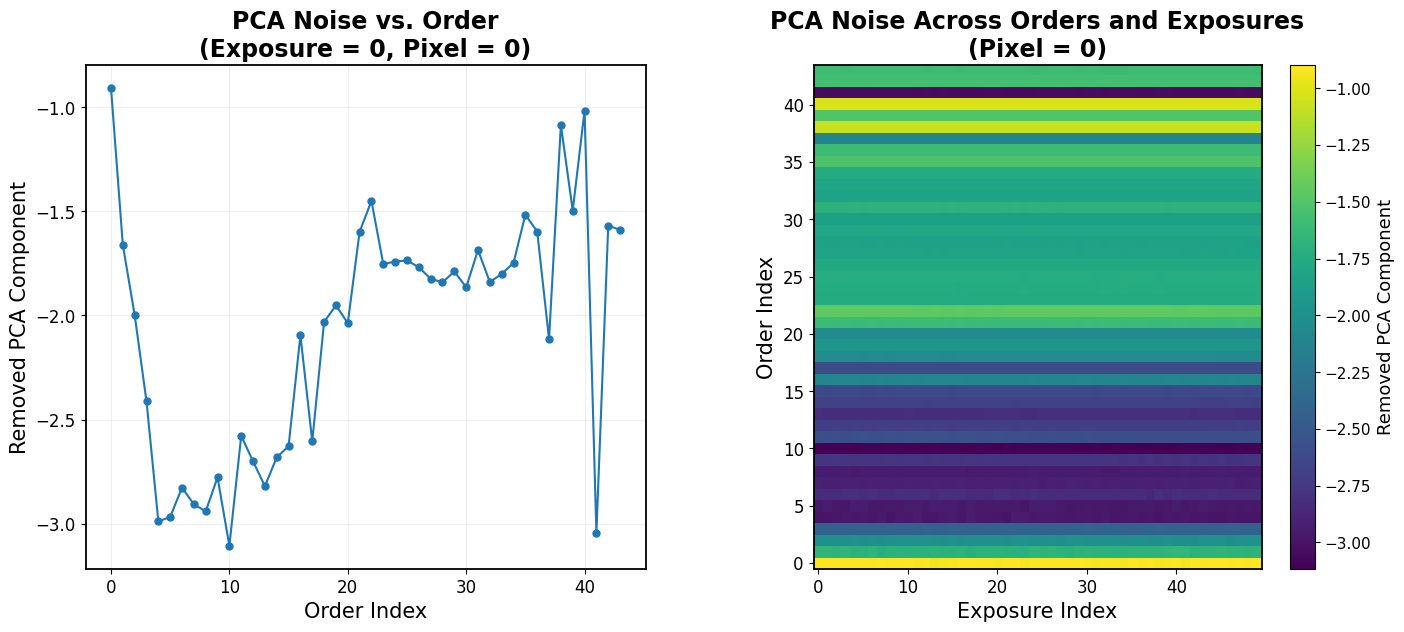

In [3]:
# read the file
file_path = '/path/to/A_noplanet'
A_noplanet = np.load(file_path, allow_pickle = True)
print(A_noplanet.shape)

n_order, n_exposure, n_pixel = A_noplanet.shape

# fix exposure and pixel index for the 1D slice
fixed_exposure = 0
fixed_pixel = 0

baseline_vs_order = A_noplanet[:, fixed_exposure, fixed_pixel]

# set up a two-panel figure: the 1D slice, and the full order x exposure structure at this pixel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

ax1.plot(range(n_order), baseline_vs_order, marker = 'o', markersize = 5, color = '#1f77b4', linewidth = 1.5)
ax1.set_title(f'PCA Noise vs. Order\n(Exposure = {fixed_exposure}, Pixel = {fixed_pixel})', fontsize = 17, weight = 'bold')
ax1.set_xlabel('Order Index', fontsize = 15)
ax1.set_ylabel('Removed PCA Component', fontsize = 15)
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)
for spine in ax1.spines.values():
    spine.set_linewidth(1.3)

im = ax2.imshow(A_noplanet[:, :, fixed_pixel], aspect = 'auto', origin = 'lower', cmap = 'viridis')
ax2.set_title(f'PCA Noise Across Orders and Exposures\n(Pixel = {fixed_pixel})', fontsize = 17, weight = 'bold')
ax2.set_xlabel('Exposure Index', fontsize = 15)
ax2.set_ylabel('Order Index', fontsize = 15)
ax2.tick_params(labelsize = 12)
for spine in ax2.spines.values():
    spine.set_linewidth(1.3)
cbar = fig.colorbar(im, ax = ax2)
cbar.set_label('Removed PCA Component', fontsize = 13)
cbar.ax.tick_params(labelsize = 11)

fig.subplots_adjust(top = 0.85, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.3)
plt.show()

This dataset has 44 spectral orders, 50 exposures, and 1848 pixels, dimensions we'll keep referring back to. The left panel shows the removed PCA component versus spectral order at one fixed exposure and pixel. The right panel shows the fuller picture at that same pixel: how the removed component varies across every order and every exposure at once, useful for spotting whether certain orders or time periods carry unusually large trends.

### `ccfs_..._150.txt`

This file holds the cross-correlation function (CCF) values from the simulation, computed by comparing the model against the observed data cube across a grid of systemic velocities and planetary semi-amplitudes. The filename follows the same convention as `A_noplanet` above.

The file itself is a plain text grid of numbers, one CCF value per `(Kp, v_sys)` combination:

```bash
3.760819399147034003e-01 -3.117153473307011646e-01 -8.649365097908588984e-01 -4.444339709537158400e-01
```

Since it's a 2D grid over two physical parameters, the natural way to look at it is a heatmap.

(200, 200)


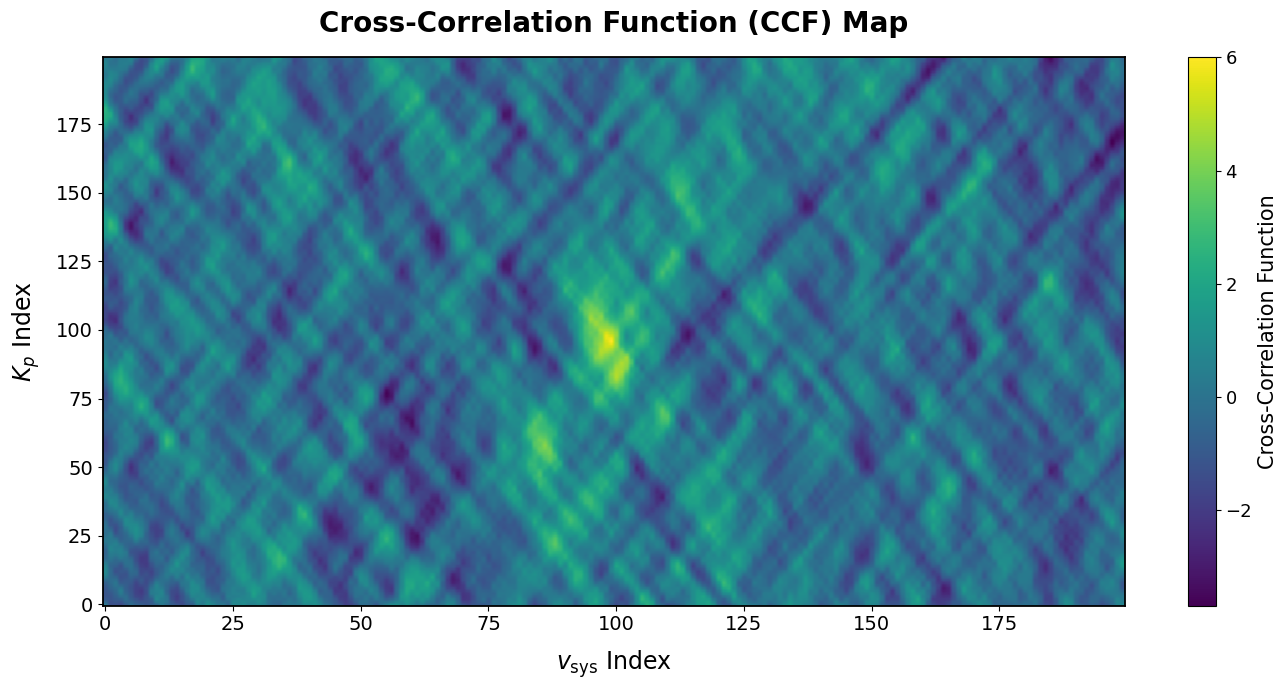

In [4]:
# read the file
file_path = '/path/to/ccf'
ccf = np.loadtxt(file_path)
print(ccf.shape)

fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

im = ax.imshow(ccf, origin = 'lower', aspect = 'auto', cmap = 'viridis')

ax.set_title('Cross-Correlation Function (CCF) Map', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel(r'$v_{\mathrm{sys}}$ Index', fontsize = 17, labelpad = 10)
ax.set_ylabel(r'$K_p$ Index', fontsize = 17, labelpad = 10)

ax.tick_params(axis = 'both', which = 'major', labelsize = 14)

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

cbar = fig.colorbar(im, ax = ax)
cbar.set_label('Cross-Correlation Function', fontsize = 15)
cbar.ax.tick_params(labelsize = 13)

plt.tight_layout()
plt.show()

A bright spot near the center suggests a detection, and it gets more pronounced as SNR increases. At low SNR, or with SNR set to zero, the map is dominated by noise instead. Keep in mind the axes here are grid indices, not physical values, `Kp` and `v_sys` in km/s, the actual values behind each index live in your run's `input.txt` output.

### `just_tellurics_vary_airmass.txt`

This file holds simulated spectra showing how telluric absorption varies with airmass, no stellar or planetary signal included, just Earth's atmosphere. Same binary pickle format, same `(n_order, n_exposure, n_pixel)` structure as `A_noplanet`.

Airmass changes over the course of an observation, so exposure here really does correspond to time. We'll plot against exposure index directly, since that's the axis this file's variation is tied to.

(44, 50, 1848)


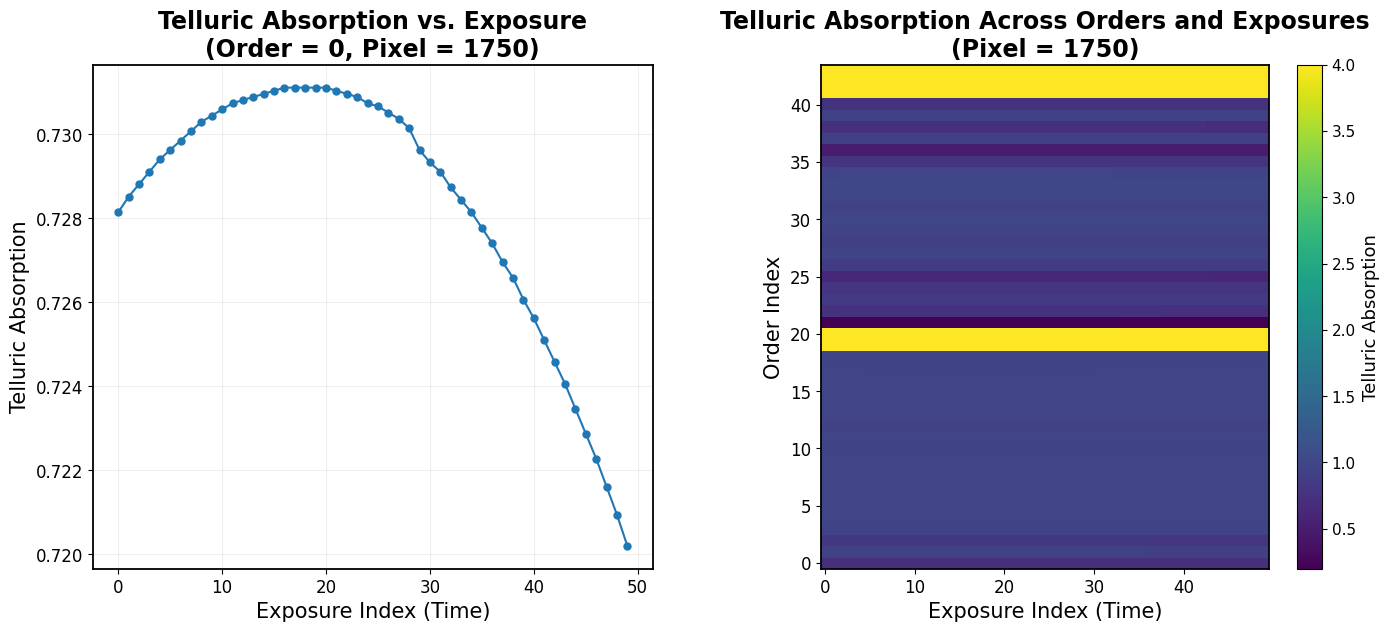

In [5]:
# read the file
file_path = '/path/to/tellurics'
just_tellurics = np.load(file_path, allow_pickle = True)
print(just_tellurics.shape)

n_order, n_exposure, n_pixel = just_tellurics.shape

# fix order and pixel index, look across exposures (time / airmass)
fixed_order = 0
fixed_pixel = 1750

transmission_vs_exposure = just_tellurics[fixed_order, :, fixed_pixel]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

ax1.plot(range(n_exposure), transmission_vs_exposure, marker = 'o', markersize = 5, color = '#1f77b4', linewidth = 1.5)
ax1.set_title(f'Telluric Absorption vs. Exposure\n(Order = {fixed_order}, Pixel = {fixed_pixel})', fontsize = 17, weight = 'bold')
ax1.set_xlabel('Exposure Index (Time)', fontsize = 15)
ax1.set_ylabel('Telluric Absorption', fontsize = 15)
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)
for spine in ax1.spines.values():
    spine.set_linewidth(1.3)

im = ax2.imshow(just_tellurics[:, :, fixed_pixel], aspect = 'auto', origin = 'lower', cmap = 'viridis')
ax2.set_title(f'Telluric Absorption Across Orders and Exposures\n(Pixel = {fixed_pixel})', fontsize = 17, weight = 'bold')
ax2.set_xlabel('Exposure Index (Time)', fontsize = 15)
ax2.set_ylabel('Order Index', fontsize = 15)
ax2.tick_params(labelsize = 12)
for spine in ax2.spines.values():
    spine.set_linewidth(1.3)
cbar = fig.colorbar(im, ax = ax2)
cbar.set_label('Telluric Absorption', fontsize = 13)
cbar.ax.tick_params(labelsize = 11)

fig.subplots_adjust(top = 0.85, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.3)
plt.show()

The left panel shows telluric absorption drifting across the observation, this is airmass changing as the target moves across the sky, exactly the effect this file is named for. The right panel adds spectral order into the picture, some orders sit at wavelengths where Earth's atmosphere absorbs more strongly than others, so certain rows show deeper, more variable absorption than others.

### `lls_..._150.txt`

This file holds log-likelihood values across the same `(Kp, v_sys)` grid as the CCF file, comparing the observed data against a planetary model while accounting for PCA-removed trends. Same filename convention as before.

```bash
1.566160162754494138e+07 1.566159355261623301e+07 1.566158934464974143e+07 1.566159427737087198e+07
```

Like the CCF file, this is a plain 2D grid, so a heatmap is again the natural way to look at it.

(200, 200)


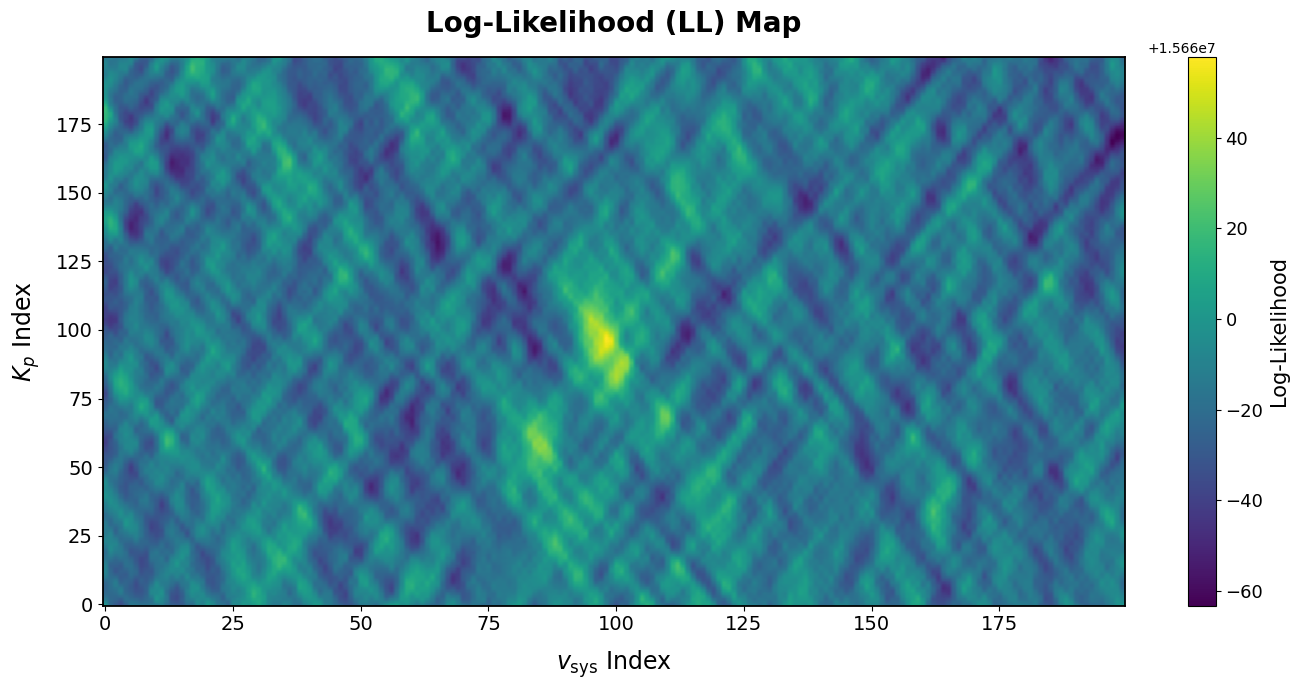

In [6]:
# read the file
file_path = '/path/to/lls'
lls = np.loadtxt(file_path)
print(lls.shape)

fig, ax = plt.subplots(figsize = (14, 7))
fig.patch.set_facecolor('white')

im = ax.imshow(lls, origin = 'lower', aspect = 'auto', cmap = 'viridis')

ax.set_title('Log-Likelihood (LL) Map', fontsize = 20, weight = 'bold', pad = 18)
ax.set_xlabel(r'$v_{\mathrm{sys}}$ Index', fontsize = 17, labelpad = 10)
ax.set_ylabel(r'$K_p$ Index', fontsize = 17, labelpad = 10)

ax.tick_params(axis = 'both', which = 'major', labelsize = 14)

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

cbar = fig.colorbar(im, ax = ax)
cbar.set_label('Log-Likelihood', fontsize = 15)
cbar.ax.tick_params(labelsize = 13)

plt.tight_layout()
plt.show()

This looks a lot like the CCF heatmap, both show a bright peak near the center from the same strong, high-SNR detection. The colors carry different meanings though: this map is log-likelihood, the CCF map is correlation strength, two related but distinct measures of how well the model fits.

### `nopca_simdata_..._150.txt` and `simdata_..._150.txt`

These two files are the most important pair in the output folder, and the best way to understand them is side by side. Both hold the full simulated dataset, planet, star, tellurics, and noise, but `nopca_simdata` is captured before PCA runs, and `simdata` after. This is the actual dataset `calc_ccf` compares against a model template, the same role my first tutorial's Doppler-off spectrum plays: real signal, cleaned of everything that doesn't move with the planet.

Let's start with the raw arrays, one exposure, plotted by pixel index, before converting to real units.

(44, 50, 1848)
(44, 50, 1848)


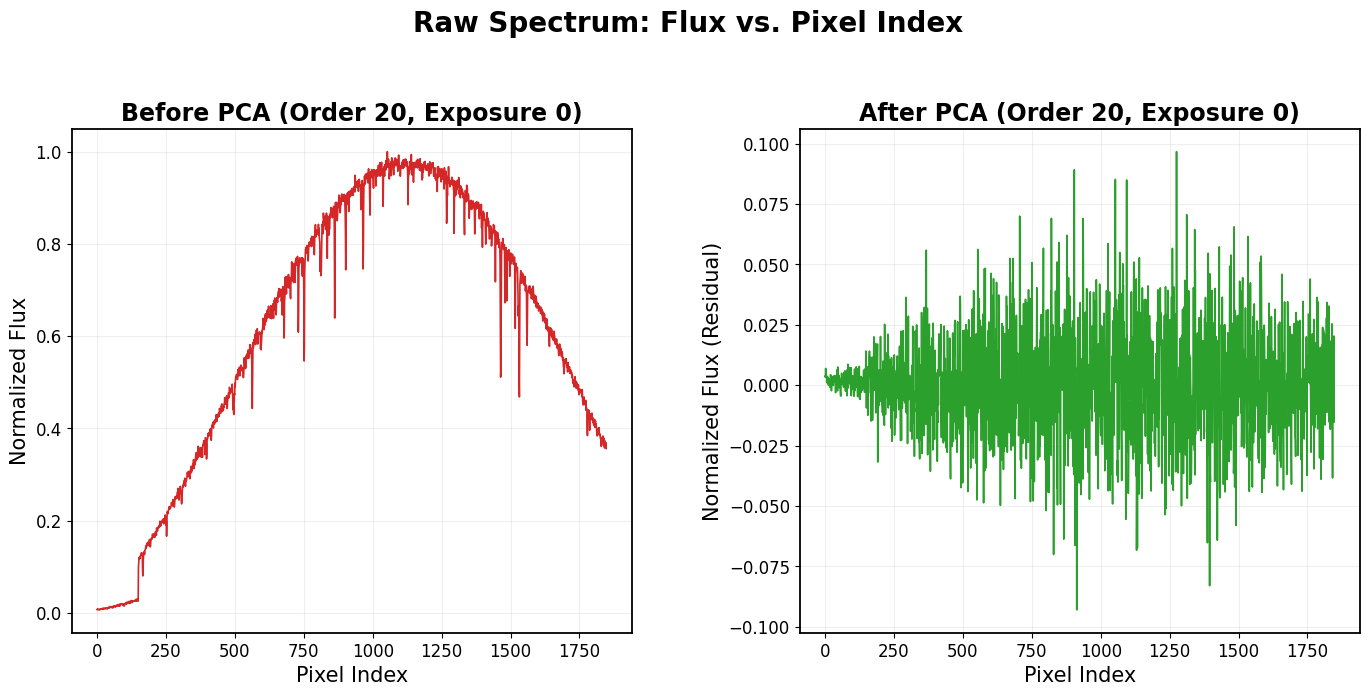

In [7]:
# read the pre-PCA and post-PCA data cubes
nopca_sim = np.load('/path/to/nopca', allow_pickle = True)
simdata = np.load('/path/to/simdata', allow_pickle = True)

print(nopca_sim.shape)
print(simdata.shape)

# pick one representative order and exposure to display
fixed_order = 20
fixed_exposure = 0

flux_before = nopca_sim[fixed_order, fixed_exposure, :]
flux_after = simdata[fixed_order, fixed_exposure, :]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))
fig.patch.set_facecolor('white')

ax1.plot(flux_before, color = '#d62728', linewidth = 1.2)
ax1.set_title(f'Before PCA (Order {fixed_order}, Exposure {fixed_exposure})', fontsize = 17, weight = 'bold')
ax1.set_xlabel('Pixel Index', fontsize = 15)
ax1.set_ylabel('Normalized Flux', fontsize = 15)
ax1.grid(True, alpha = 0.2)
ax1.tick_params(labelsize = 12)
for spine in ax1.spines.values():
    spine.set_linewidth(1.3)

ax2.plot(flux_after, color = '#2ca02c', linewidth = 1.2)
ax2.set_title(f'After PCA (Order {fixed_order}, Exposure {fixed_exposure})', fontsize = 17, weight = 'bold')
ax2.set_xlabel('Pixel Index', fontsize = 15)
ax2.set_ylabel('Normalized Flux (Residual)', fontsize = 15)
ax2.grid(True, alpha = 0.2)
ax2.tick_params(labelsize = 12)
for spine in ax2.spines.values():
    spine.set_linewidth(1.3)

fig.suptitle('Raw Spectrum: Flux vs. Pixel Index', fontsize = 20, weight = 'bold', y = 1.02)
fig.subplots_adjust(top = 0.85, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.3)
plt.show()

Even in this single slice, PCA's effect is obvious: the smooth, large-scale shape on the left, mostly the star and instrument, flattens into something closer to noise on the right. That flatness isn't a loss of information, it's what real detection work actually looks for, a faint planetary signature that would otherwise be buried under everything static.

Pixel index alone doesn't mean much, though. Pixel maps to wavelength within this order, and exposure maps to orbital phase, the time-ordered sequence of the observation. Looking across every exposure at once, in real units, turns this into a **trail diagram**, wavelength on one axis, orbital phase on the other, the standard way this kind of data gets shown in HRCCS papers. A planet's motion shows up as a visible diagonal streak drifting across wavelength as phase changes, the same Doppler shift my first tutorial's wind-speed measurements are built to detect numerically. To build it, we need the real wavelength grid from the original data cube and the real orbital phases from `input.txt`.

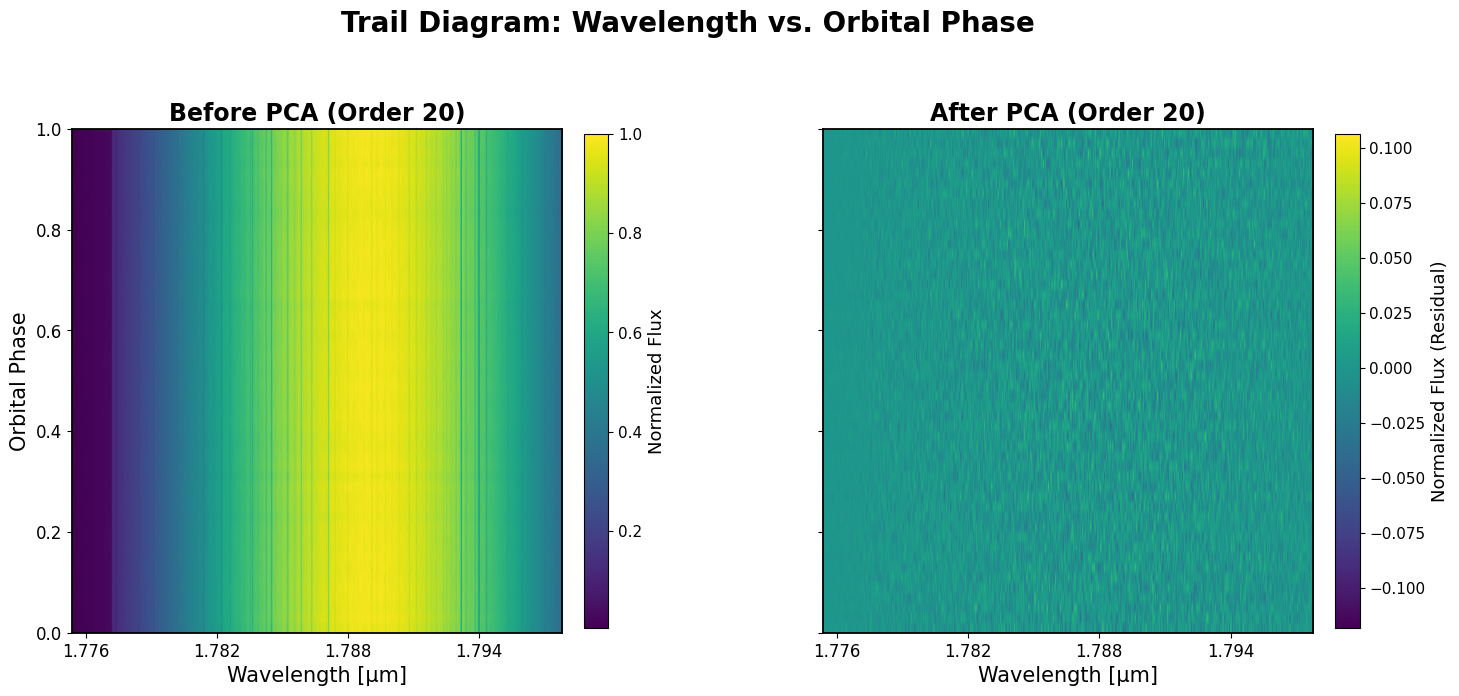

In [8]:
# reconstruct the real wavelength grid from the original data cube
data_cube_path = '/path/to/data_cube.pic'
data_cube_path = file_paths._paths.get(data_cube_path, data_cube_path)  # resolve to your real local path

mike_wave, mike_cube = pickle.load(open(data_cube_path, 'rb'), encoding = 'latin1')
wl_cube_model = mike_wave.astype(np.float64)

# reconstruct real orbital phases from input.txt values
phase_start, phase_end, n_exposures = 0, 1, 50
phases = np.linspace(phase_start, phase_end, n_exposures)

# wavelength grid for this order, already in microns
wavelength_order = wl_cube_model[fixed_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7), sharey = True)
fig.patch.set_facecolor('white')

im1 = ax1.imshow(
    nopca_sim[fixed_order], aspect = 'auto', origin = 'lower', cmap = 'viridis',
    extent = [wavelength_order.min(), wavelength_order.max(), phases.min(), phases.max()]
)
ax1.set_title(f'Before PCA (Order {fixed_order})', fontsize = 17, weight = 'bold')
ax1.set_xlabel('Wavelength [μm]', fontsize = 15)
ax1.set_ylabel('Orbital Phase', fontsize = 15)
ax1.xaxis.set_major_locator(plt.MaxNLocator(4))
ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax1.tick_params(axis = 'both', which = 'major', labelsize = 12)
for spine in ax1.spines.values():
    spine.set_linewidth(1.3)
cbar1 = fig.colorbar(im1, ax = ax1, fraction = 0.046, pad = 0.04)
cbar1.set_label('Normalized Flux', fontsize = 13)
cbar1.ax.tick_params(labelsize = 11)

im2 = ax2.imshow(
    simdata[fixed_order], aspect = 'auto', origin = 'lower', cmap = 'viridis',
    extent = [wavelength_order.min(), wavelength_order.max(), phases.min(), phases.max()]
)
ax2.set_title(f'After PCA (Order {fixed_order})', fontsize = 17, weight = 'bold')
ax2.set_xlabel('Wavelength [μm]', fontsize = 15)
ax2.xaxis.set_major_locator(plt.MaxNLocator(4))
ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax2.tick_params(axis = 'both', which = 'major', labelsize = 12)
for spine in ax2.spines.values():
    spine.set_linewidth(1.3)
cbar2 = fig.colorbar(im2, ax = ax2, fraction = 0.046, pad = 0.04)
cbar2.set_label('Normalized Flux (Residual)', fontsize = 13)
cbar2.ax.tick_params(labelsize = 11)

fig.suptitle('Trail Diagram: Wavelength vs. Orbital Phase', fontsize = 20, weight = 'bold', y = 1.02)
fig.subplots_adjust(top = 0.85, bottom = 0.13, left = 0.06, right = 0.98, wspace = 0.4)
plt.show()

Same data, now in physically meaningful units, and now showing every exposure at once rather than a single one. If a planetary signal is strong enough to see by eye, this is where it would show up: a faint diagonal streak drifting across wavelength as phase increases. `nopca_simdata` and `simdata` share the same array shape as every other file in this section, so the same approach works for a different order or exposure.

## End of Tutorial

That covers the core of `run_simulation.py` and the annotated walkthrough of `scope`'s pipeline: how a simulated dataset gets built from a planet and star model, how tellurics, blaze, and noise get layered in, how PCA isolates a faint planetary signal from everything static, and how the output files tie back to the CCF and log-likelihood maps used to detect that signal.

I wrote this because the source code, while well written, was dense enough that understanding it properly meant reading it line by line myself. If you're working with `scope` for your own research, I hope having these annotations alongside the original code saves you some of that time.

This notebook doesn't cover every function in the package, only the ones tied directly to the main simulation pipeline, so there's more to explore if you dig into `scope`'s other files. If you spot an error here, or a section that could use more explanation, feel free to open an issue on the [project repository](https://patsrnpt.github.io/Exoplanet-Atmosphere/intro.html).

If you haven't already, my first tutorial walks through the companion side of this work: using cross-correlation to detect molecular composition and measure wind speed in exoplanet atmospheres, and how instrument resolution affects what you can actually recover.

## About This Notebook

**Author:** Sarunyapat (Pat) Phoompuang, Imperial College London ([sphoom22@terpmail.umd.edu](mailto:sphoom22@terpmail.umd.edu))

**Package Author:** Arjun Savel, University of Maryland, College Park ([asavel@umd.edu](mailto:asavel@umd.edu))

**Research Advisor:** Dr. Hayley Beltz, University of Kansas ([hbeltz@ku.edu](mailto:hbeltz@ku.edu))

These annotations were written with Arjun's permission, alongside the original `scope` source code. `scope` itself is released under the BSD 3-Clause License; see the [official repository](https://github.com/arjunsavel/scope) for the license and full source.

Last updated: September, 2026